In [16]:
import pandas as pd
import glob

import datetime as datetime
import pandas as pd
from dataIO import dataloader, webservices
from statisticscalculator import generalstatistics, climatestatistics
from plot_collection import stackedlineplots, streamflow_stat_plots, streamflow_stat_plots_matplotlib
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.mixture import GaussianMixture
import seaborn as sns

In [17]:
headwater_sites = {
    'So Fk Mckenzie River Abv Cougar Lake Nr Rainbow OR': [14159200, 'Willamette', 'Mckenzie River'],
    'Lookout Creek Near Blue River, OR': [14161500, 'Willamette', 'Mckenzie River'],
    'South Santiam River Below Cascadia, OR': [14185000, 'Willamette', 'South Santiam River'],
    'Quartzville Creak Near Cascadia, OR': [14185900, 'Willamette', 'South Santiam River'],
    'Blowout Creek Near Detroit, OR': [14180300, 'Willamette', 'North Santiam River'],
    'No Santiam R Blw Boulder Crk, Nr Detroit, OR': [14178000, 'Willamette', 'North Santiam River'],
    'Breitenbush R Abc French Cr Nr Detroit, OR': [14179000, 'Willamette', 'North Santiam River'],
    'South Fork Bull Run River Near Bull Run, OR': [14139800, 'Willamette', 'Bull Run'],    
    'West Fork Bitteroot River nr Conner MT': [12342500, 'Pend Oreille'],
    'Bitterroot River near Darby MT': [12344000, 'Pend Oreille'],
    'Middle Fork Rock Cr Philipsburg, MT': [12332000, 'Pend Oreille'],
    'Clark Fork ab Little Blackfoot R nr Garrison MT': [12324400, 'Pend Oreille'],
    'Little Blackfoot River near Garrison MT': [12324590, 'Pend Oreille'],
    'Swan River near Bigfork, MT': [12370000, 'Pend Oreille'],
    'Blackfoot R ab Nevada Cr nr Helmville MT': [12335100, 'Pend Oreille'],
    'S F Flathead R ab Twin C nr Hungry Horse MT': [12359800, 'Pend Oreille'],
    'St Joe River at Red Ives Ranger Station, ID': [12413875, 'Spokane'],
    'St Joe River at Ramsdell Nr St Maries ID': [12415135, 'Spokane'],
    'St Maries River Nr Santa, ID': [12414900, 'Spokane'],
    'Nf Coeur D Alene R Ab Shoshone Ck Nr Prichard ID': [12411000, 'Spokane'],
    'Nf Clearwater River Nr Canyon Ranger Station ID': [13340600, 'Clearwater'],
    'Lochsa River Nr Lowell ID': [13337000, 'Clearwater'],
    'Selway River Nr Lowell ID': [13336500, 'Clearwater'],
    'Sf Clearwater River At Stites ID': [13338500, 'Clearwater'],
    'Lemhi River Below L5 Diversion Near Salmon ID': [13305310, 'Salmon'],
    'Pahsimeroi River at Ellis ID': [13302005, 'Salmon'],
    'Salmon River Nr Shoup ID': [13307000, 'Salmon'],
    'Sf Salmon River Nr Krassel Ranger Station ID': [13310700, 'Salmon'],
    'Tobacco River at Eureka, MT': [12301250, 'Kootenay'],
    'Fisher River near Libby, MT': [12302055, 'Kootenay'],
    'Yaak River near Troy, MT': [12304500, 'Kootenay'],
    'Moyie River At Eastport ID': [12306500, 'Kootenay'],
    'Similkameen River Near Nighthawk, WA':[12442500, 'Upper Tributaries'],
    'Methow River At Winthrop, WA': [12448500, 'Upper Tributaries'],
    'Stehekin River At Stehekin, WA': [12451000, 'Upper Tributaries'],
    'Chiwawa River Near Plain, WA': [12456500, 'Upper Tributaries'],  #Wenatchee River side river
    'Wenatchee River at Plain, WA': [12457000, 'Upper Tributaries'], #Wenatchee Lake above this point.  Don't think it's regulated though.
    'Entiat River Near Entiat, WA': [12452990, 'Upper Tributaries'],
    'John Day River Near John Day, OR': [14038530, 'Lower Tributaries', 'John Day'],
    'Middle Fork John Day River At Ritter, OR': [14044000, 'Lower Tributaries', 'John Day'],
    'John Day River At Mcdonald Ferry, OR': [14048000, 'Lower Tributaries', 'John Day'],
    'Metolius River Near Grandview, OR': [14091500, 'Lower Tributaries', 'Deschutes'],
    'Shitike Crek Near Warm Springs, OR': [14093000, 'Lower Tributaries', 'Deschutes'],
    'Warm Springs River Near Kahneeta Hot Springs, OR': [14097100, 'Lower Tributaries', 'Deschutes'],
    'White River Below Tygh Valley, OR': [14101500, 'Lower Tributaries', 'Deschutes'],
    'Crooked River Blw Osborne Canyon, Nr Opal City, OR':[14087380, 'Lower Tributaries', 'Deschutes'],
    'Owyhee River Nr Rome, OR': [13181000, 'Middle Snake-Boise'],
    'Boise River Nr Twin Springs, ID':[13185000, 'Middle Snake-Boise'],
    'Sf Boise River Nr Featherville ID': [13186000, 'Middle Snake-Boise'],
    'South Fork Payette River At Lowman, ID': [13235000, 'Middle Snake-Boise'],
    'Payette River Nr Horseshoe Bend ID': [13247500, 'Middle Snake-Boise'],
    'Weiser River Nr Cambridge ID': [13258500, 'Middle Snake-Boise'],
    'Fall River Ab Yellowstone Canal Nr Squirrel ID': [13046995, 'Upper Snake'],
    'Teton River Ab South Leigh Creek Nr Driggs ID': [13052200, 'Upper Snake'],
    'Willow Crrek Nr Ririe ID': [13058000, 'Upper Snake'],
    'Blackfoot River Ab Reservoir Nr Henry ID': [13063000, 'Upper Snake'],
    'Portneuf River At Topad ID': [13073000, 'Upper Snake'],
    'Big Wood R At S Broadford Brige Nr Bellevue ID': [13140335, 'Upper Snake'],
    'Salt River Above Reservoir, Near Etna, WY': [13027500, 'Snake Headwaters'],
    'Gros Ventre River At Zenith, WY': [13015000, 'Snake Headwaters'],
    'Buffalo Fork Ab Lava Creek Nr Moran WY': [13011900, 'Snake Headwaters'],
    'Hoback River Near Jackson, WY': [13019500, 'Snake Headwaters'],

}        

In [45]:
volume_stats_for_vip_sites = {}


for site in headwater_sites.items():
    try:
        basin = site[1][1]
        data = webservices.usgs_streamflow().get_data(parameterCd='00010', start_date='1921-10-01', end_date=datetime.datetime.now().strftime('%Y-%m-%d'),sites=str(site[1][0])).reset_index()
        d = dataloader.DataLoader(data, 'Date', name_of_Q_column='Discharge')
        s = climatestatistics.Streamflow(d)
    # except Exception as e:
    #     print(e)
    # finally:
    #     pass
    
    
# print('-------------------------------------------------')  

        mann_kendall_results = {}
        s.calc_annual_runoff_threshold_day(0.5, alpha=.1)  #have to run this one still so total temp is calculated
        s.calc_max(calc_from_rolling_median=False, window_size=7)
        print(f'Mann-Kendall Test Results looking for trend in day of year on peak temperature dates: {s.rolling_yr_Qmax_mk_test}')
        print(f'Mann-Kendall Test Results looking for trend in temperature on peak temperature dates: {s.rolling_yr_DOYmax_mk_test}')
    #     peak_runoff_plot = streamflow_stat_plots.Plot_Peak_Runoff(s)
    #     peak_runoff_plot = peak_runoff_plot.plot_peak_runoff(site[0])
        print('-------------------------------------------------')  
    
        
    #     for day in ['01-01', '03-01', '05-01', '08-01']:
        s.calc_runoff_bw_days(begin_month_day='01-01', end_month_day='12-31', alpha=.1)
        print(f'Mann-Kendall Test Results looking for trend in temperature from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
    #     runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
    #     runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
    
        print('-------------------------------------------------')
        

        


        s.calc_runoff_bw_days(begin_month_day='10-01', end_month_day='12-31', alpha=.1)
        print(f'Mann-Kendall Test Results looking for trend in temperature from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
        runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
        # runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
        mann_kendall_results['Fall Temp']=s.volume_bw_days_mann_kendall_test
        print('-------------------------------------------------')
    #     for day in ['01-01', '03-01', '05-01', '08-01']:
        s.calc_runoff_bw_days(begin_month_day='01-01', end_month_day='04-01', alpha=.1)
        print(f'Mann-Kendall Test Results looking for trend in temperature from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
        runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
        # runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
        mann_kendall_results['Winter Temp']=s.volume_bw_days_mann_kendall_test
        print('-------------------------------------------------')
    #     for day in ['01-01', '03-01', '05-01', '08-01']:
        s.calc_runoff_bw_days(begin_month_day='07-01', end_month_day='10-01', alpha=.1)
        print(f'Mann-Kendall Test Results looking for trend in temperature from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
    #     runoff_bw_dates_plot2 = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
    #     runoff_bw_dates_plot2.plot_runoff_volume_between_2days(site[0])
        mann_kendall_results['Summer Temp'] = s.volume_bw_days_mann_kendall_test
        print('-------------------------------------------------')            
    #     for day in ['01-01', '03-01', '05-01', '08-01']:
    #     s.calc_runoff_bw_days(begin_month_day='05-01', end_month_day='7-01', alpha=.1)
    #     print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
    #     runoff_bw_dates_plot3 = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
    #     runoff_bw_dates_plot3.plot_runoff_volume_between_2days(site[0])
       
        
        mann_kendall_results['T on date of peak T date MK Test'] = s.rolling_yr_Qmax_mk_test
        mann_kendall_results['dayofyear on date of peak T date MK Test'] = s.rolling_yr_DOYmax_mk_test
        mann_kendall_results['Total T MK Test'] = s.total_volume_mann_kendall_test
        mann_kendall_results['Basin'] = basin
        print(mann_kendall_results)
        volume_stats_for_vip_sites[site[0]] = mann_kendall_results
    except Exception as e:
        print(e)
        pass
    # finally:
    #     pass
print('---------------------------------------------------------------------------------------------------')    
#     historical_plot = stackedlineplots.StaticPlotter(s,
#             water_year_on=True,
#             title=site[0],
#             highlight_years=[2024],
#             plot_central_tendency_stats=True,
#             quartile_shading=False, 
# #             quartile_shading_alpha=0.00,
#             series_labels=False,
#             series_alpha=.1,
# #                     y_upper_lim=20000,
#             y_lower_lim=0,
#             legend_pos="best",
#             legend_mode="partial",
#             legend_ncol=1,)


#     with open('statplots.html', 'a') as f:
#         f.write(peak_runoff_plot.plot_peak_runoff(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(threshold_runoff_plot.plot_runoff_threshold(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot2.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot3.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))   
    #         f.write(historical_plot.to_html(full_html=False, include_plotlyjs='cdn'))

https://waterservices.usgs.gov/nwis/dv/?format=json&sites=14159200&startDT=1921-10-01&endDT=2024-07-03&siteStatus=all&parameterCd=00010
Mann-Kendall Test Results looking for trend in day of year on peak temperature dates: Mann_Kendall_Test(trend='decreasing', h=True, p=0.0017935705058447216, z=-3.122442641996404, Tau=-0.27181385510312006, s=-514.0, var_s=26992.666666666668, slope=-0.023684210526315797, intercept=15.222368421052632)
Mann-Kendall Test Results looking for trend in temperature on peak temperature dates: Mann_Kendall_Test(trend='no trend', h=False, p=0.1254229191409093, z=-1.5324033993158144, Tau=-0.1337916446324696, s=-253.0, var_s=27043.0, slope=-0.16326530612244897, intercept=214.4795918367347)
-------------------------------------------------
Mann-Kendall Test Results looking for trend in temperature from 01-01 to 12-31: Mann_Kendall_Test(trend='no trend', h=False, p=0.22874529700344448, z=1.2035972135528599, Tau=0.12684989429175475, s=120.0, var_s=9775.333333333334, sl

In [43]:
mann_kendall_results

{'Fall Temp': Mann_Kendall_Test(trend='no trend', h=False, p=0.2962698714842864, z=1.044465935734187, Tau=1.0, s=3.0, var_s=3.6666666666666665, slope=0.19065, intercept=0.16275000000000006),
 'Winter Temp': Mann_Kendall_Test(trend='no trend', h=False, p=0.2962698714842864, z=1.044465935734187, Tau=1.0, s=3.0, var_s=3.6666666666666665, slope=0.15695, intercept=0.10455),
 'Summer Temp': Mann_Kendall_Test(trend='no trend', h=False, p=0.2962698714842864, z=-1.044465935734187, Tau=-1.0, s=-3.0, var_s=3.6666666666666665, slope=-0.6838500000000002, intercept=2.02555),
 'T on date of peak T date MK Test': Mann_Kendall_Test(trend='no trend', h=False, p=0.2962698714842864, z=-1.044465935734187, Tau=-1.0, s=-3.0, var_s=3.6666666666666665, slope=-1.0000000000000009, intercept=18.4),
 'dayofyear on date of peak T date MK Test': Mann_Kendall_Test(trend='no trend', h=False, p=0.2962698714842864, z=-1.044465935734187, Tau=-1.0, s=-3.0, var_s=3.6666666666666665, slope=-15.0, intercept=221.0)}

In [42]:
volume_stats_for_vip_sites

{}

In [46]:
sites = []
basins = []

PeakT_trend = []
PeakT_h = []
PeakT_p = []
PeakT_tau = []

PeakTDOY_trend = []
PeakTDOY_h = []
PeakTDOY_p = []
PeakTDOY_tau = []

TotalT_trend = []
TotalT_h = []
TotalT_p = []
TotalT_tau = []

SummerT_trend = []
SummerT_h = []
SummerT_p = []
SummerT_tau = []

WinterT_trend = []
WinterT_h = []
WinterT_p = []
WinterT_tau = []

FallT_trend = []
FallT_h = []
FallT_p = []
FallT_tau = []

for site in volume_stats_for_vip_sites.items():
    
    sites.append(site[0])
    basins.append(site[1]['Basin'])
    
    PeakT_trend.append(site[1]['T on date of peak T date MK Test'][0])
#     PeakRunoff_h.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakT_p.append(site[1]['T on date of peak T date MK Test'][2])
    PeakT_tau.append(site[1]['T on date of peak T date MK Test'][4])
    
    PeakTDOY_trend.append(site[1]['dayofyear on date of peak T date MK Test'][0])
#     PeakRunoff_h.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakTDOY_p.append(site[1]['dayofyear on date of peak T date MK Test'][2])
    PeakTDOY_tau.append(site[1]['dayofyear on date of peak T date MK Test'][4])    
        
    TotalT_trend.append(site[1]['Total T MK Test'][0])
#     TotalVol_h.append(site[1]['Total Vol MK Test'][2])
    TotalT_p.append(site[1]['Total T MK Test'][2])
    TotalT_tau.append(site[1]['Total T MK Test'][4])
    
    SummerT_trend.append(site[1]['Summer Temp'][0])
#     Volbwdays_h.append(site[1]['Vol bw days MK Test'][2])
    SummerT_p.append(site[1]['Summer Temp'][2])
    SummerT_tau.append(site[1]['Summer Temp'][4])
    
    WinterT_trend.append(site[1]['Winter Temp'][0])
    WinterT_p.append(site[1]['Winter Temp'][2])
    WinterT_tau.append(site[1]['Winter Temp'][4])

    FallT_trend.append(site[1]['Fall Temp'][0])
    FallT_p.append(site[1]['Fall Temp'][2])
    FallT_tau.append(site[1]['Fall Temp'][4])
#     PeakRunoffMKTest['trend']=site[1]['Peak Runoff MK Test'][1]
#     PeakRunoffMKTest['h']=site[1]['Peak Runoff MK Test'][2]
#     PeakRunoffMKTest['p']=site[1]['Peak Runoff MK Test'][3]
#     PeakRunoffMKTest['Tau']=site[1]['Peak Runoff MK Test'][5]

In [47]:
peakT = pd.DataFrame({'sites':sites, 'basin': basins, 'trend': PeakT_trend,  'p': PeakT_p, 'tau': PeakT_tau})
peakTDOY = pd.DataFrame({'sites':sites, 'basin': basins,'trend': PeakTDOY_trend,  'p': PeakTDOY_p, 'tau': PeakTDOY_tau})
totalT = pd.DataFrame({'sites':sites, 'basin': basins,'trend': TotalT_trend, 'p': TotalT_p, 'tau': TotalT_tau})
summerT = pd.DataFrame({'sites':sites, 'basin': basins,'trend': SummerT_trend, 'p': SummerT_p, 'tau': SummerT_tau})
winterT = pd.DataFrame({'sites':sites, 'basin': basins,'trend': WinterT_trend, 'p': WinterT_p, 'tau': WinterT_tau})
fallT = pd.DataFrame({'sites':sites, 'basin': basins,'trend': FallT_trend, 'p': FallT_p, 'tau': FallT_tau})

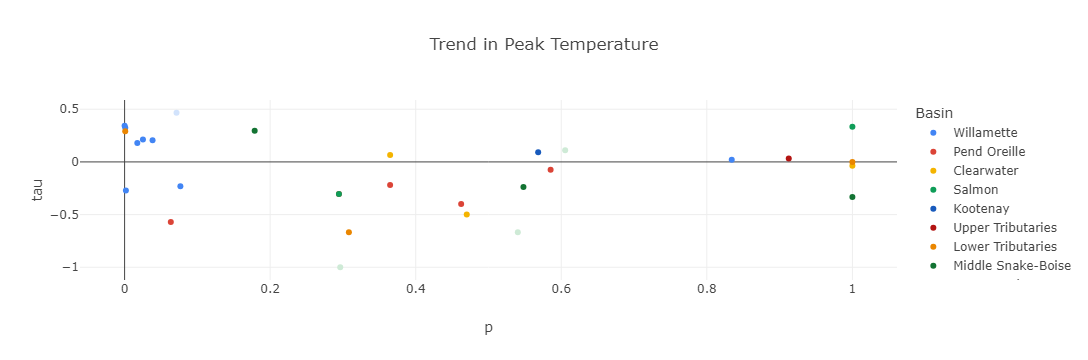

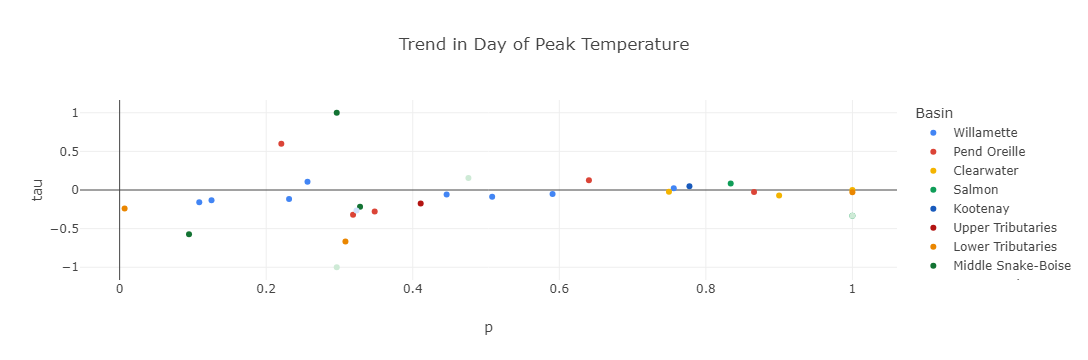

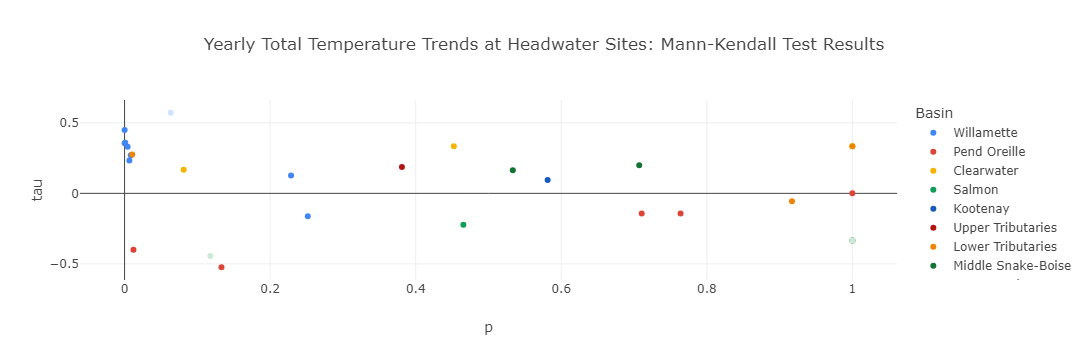

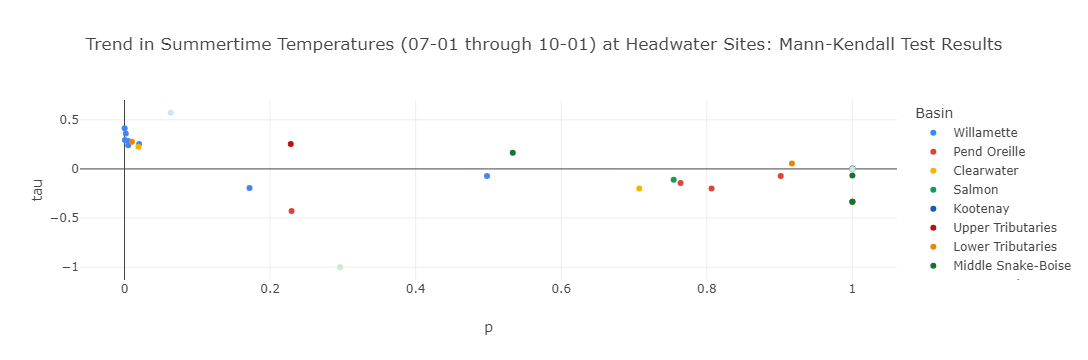

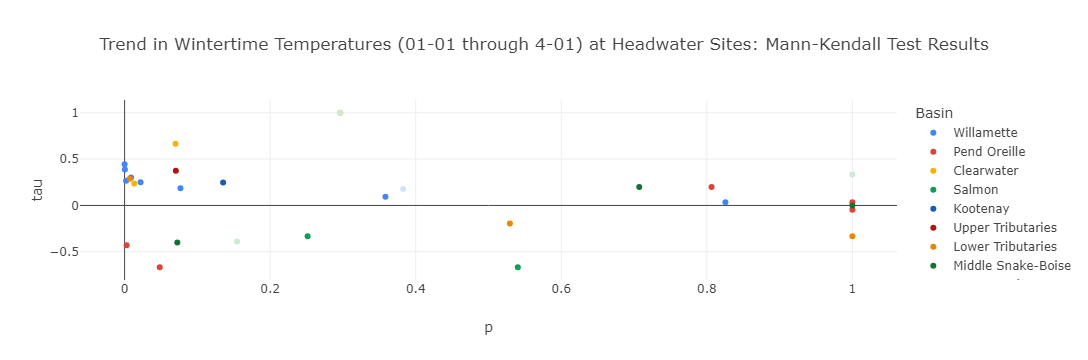

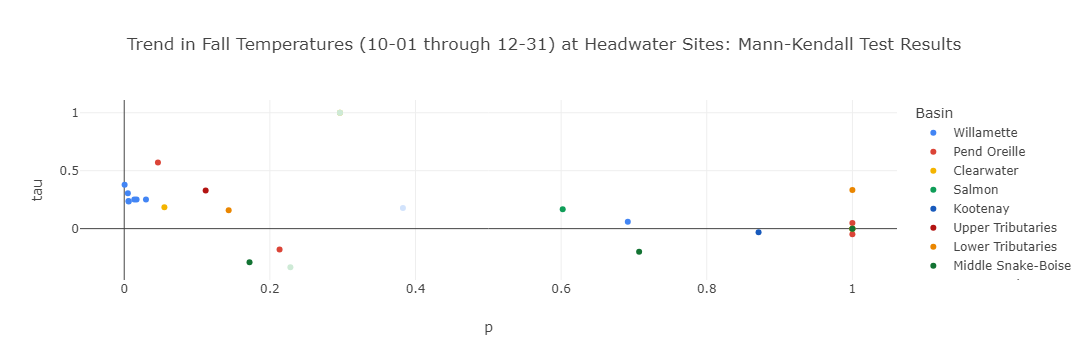

In [62]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.validators.scatter.marker import SymbolValidator
vals = SymbolValidator().values
import plotly.io as pio
# pio.templates.default = 'plotly_white'
pio.templates["google"] = go.layout.Template(
    layout_colorway=['#4285F4', '#DB4437', '#F4B400', '#0F9D58',
                     '#185ABC', '#B31412', '#EA8600', '#137333',
                     '#d2e3fc', '#ceead6']
)

# setting Google color palette as default
pio.templates.default = "google"


for result in [
    ('peakT', peakT), 
    ('PeakTDOY', peakTDOY), 
    ('totalT',totalT),
    ('summerT',summerT),
    ('winterT', winterT),
    ('fallT', fallT)
    ]:
    # kmeans = KMeans(n_clusters=4, init='random')
    # kmeans.fit(result[1][['p','tau']])
#     fig = px.scatter(result, 'p', 'tau', color=kmeans.labels_,
# #                      title=f'{result}',
#                      hover_data={'Cluster': kmeans.labels_, 'Site': result['sites'], 'Trend': result['trend']},
#                      labels={'color':'Cluster'})

    fig = go.Figure()
    
    
#     marker_styles = {
#     'increasing': {'color':'green', 'symbol':'triangle-up', 'size': 10},
#     'decreasing': {'color':'red', 'symbol':'triangle-down', 'size': 10},
#     'no trend': {'color':'blue', 'symbol':'circle', 'size': 5}
#     }
    
# #     for site in result[1]['sites'].unique():
# #         site_data = result[1][result[1]['sites']==site]
# #         fig.add_trace(
# #             go.Scatter(
# #                 y=site_data['tau'],
# #                 x=site_data['p'],
# #                 mode='markers',
# #                 name=site,
# #                 text = site_data
# #             )
# #         )
    
#     for trend in result[1]['trend'].unique():
#         trend_data = result[1][result[1]['trend']==trend]
#         fig.add_trace(
#             go.Scatter(
#                 y=trend_data['tau'],
#                 x=trend_data['p'],
#                 mode='markers',
#                 name=trend,
#                 marker=dict(
#                     color=marker_styles[trend]['color'],
#                     symbol=marker_styles[trend]['symbol'],
#                     size=marker_styles[trend]['size']),
#                 text = trend_data['sites'],
#                 hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}'
                
                
#             )
#         )

    marker_styles = {
    'increasing': {'color':'green', 'symbol':'triangle-up', 'size': 10},
    'decreasing': {'color':'red', 'symbol':'triangle-down', 'size': 10},
    'no trend': {'color':'blue', 'symbol':'circle', 'size': 5}
    }


    # def Setshape (x):
    #     vals = SymbolValidator().values
    #     return vals[3*x]
    
    for basin in result[1]['basin'].unique():
        basin_data = result[1][(result[1]['basin']==basin)]
        # basin_data = result[1][result[1]['basin']==basin]
        # print(basin_data)
        # print(list(basin_data['trend'])[0])
        # print(marker_styles[basin_data['trend'][0]]['symbol'])
        fig.add_trace(
            go.Scatter(
                y=basin_data['tau'],
                x=basin_data['p'],
                mode='markers',
                name=basin,
                # symbol =list(map(Setshape, basin_data['trend'])),
                # marker=dict(
                    # symbol=basin_data['trend']
                    # color=marker_styles[trend]['color'],
                    # symbol=marker_styles[list(basin_data['trend'])[0]]['symbol'],
                    # size=marker_styles[trend]['size']
                # ),
                text = basin_data['sites'],
                # hover_data={'Basin': basin_data['basin'], 'Site': basin_data['sites'], 'Trend': basin_data['trend'],},
                hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}<br><b>Trend:</b> %{trend}'
    
            )
        )

    # for basin in result[1]['basin'].unique():
    #     for trend in result[1]['trend'].unique():
    #         basin_data = result[1][(result[1]['trend']==trend) & (result[1]['basin']==basin)]
    #         # basin_data = result[1][result[1]['basin']==basin]
    #         # print(basin_data)
    #         # print(trend)
    #         # print(list(basin_data['trend'])[0])
    #         # print(marker_styles[basin_data['trend'][0]]['symbol'])
    #         fig.add_trace(
    #             go.Scatter(
    #                 y=basin_data['tau'],
    #                 x=basin_data['p'],
    #                 mode='markers',
    #                 name=basin,
    #                 marker=dict(
    #                     # symbol=basin_data['trend']
    #                     # color=marker_styles[trend]['color'],
    #                     # symbol=marker_styles[list(basin_data['trend'])[0]]['symbol'],
    #                     # size=marker_styles[trend]['size']
    #                 ),
    #                 text = basin_data['sites'] + 'Trend: ' + basin_data['trend'],
    #                 hovertemplate=f'<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}<br><b>Trend:</b> %{basin_data['trend']}'
        
    #             )
    #         )
    
    # for basin in result[1]['basin'].unique():
    #     basin_data = result[1][result[1]['basin']==basin]
    #     # print(basin_data['trend'])
    #     for _, row in basin_data.iterrows():
    #         # print(_)
    #         # print(row)
    #         fig.add_trace(
    #             go.Scatter(
    #                 y=basin_data['tau'],
    #                 x=basin_data['p'],
    #                 mode='markers',
    #                 name=row['basin'],
    #                 # marker=dict(
    #                     # symbol=basin_data['trend']
    #                     # color=marker_styles[trend]['color'],
    #                     # symbol=marker_styles[trend]['symbol'],
    #                 #     size=marker_styles[trend]['size']
    #                 # ),
    #                 text = row,
    #                 hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}'
        
    #             )
    #     )
        
    if result[0]=='peakT':
        title= 'Trend in Peak Temperature'
    elif result[0]=='PeakTDOY':
        title= 'Trend in Day of Peak Temperature'
    elif result[0]=='totalT':
        title= 'Yearly Total Temperature Trends at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='summerT':
        title='Trend in Summertime Temperatures (07-01 through 10-01) at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='winterT':
        title='Trend in Wintertime Temperatures (01-01 through 4-01) at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='fallT':
        title='Trend in Fall Temperatures (10-01 through 12-31) at Headwater Sites: Mann-Kendall Test Results'
       

    
    
    fig.update_layout(
        title=title,
        xaxis_title = 'p',
        yaxis_title = 'tau',
        legend_title = 'Basin',
        legend = dict(
            itemclick='toggle',
            itemdoubleclick = 'toggleothers'),
        # autosize=False,
        # width=1200,
        # height=400,
    )
    fig.show()
    
    # with open('HeadwaterSites_MK_Results.html', 'a') as f:
    #     f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

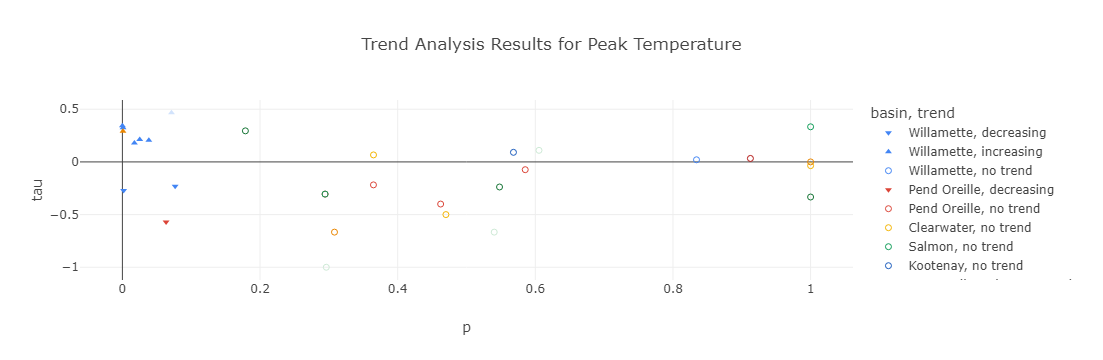

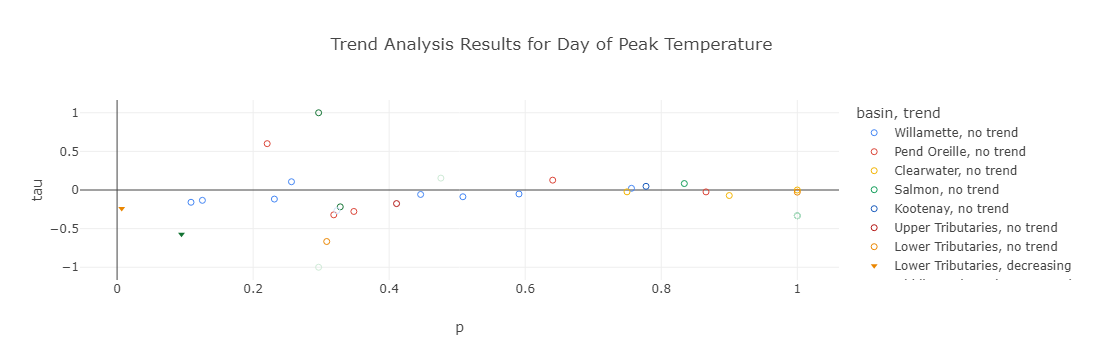

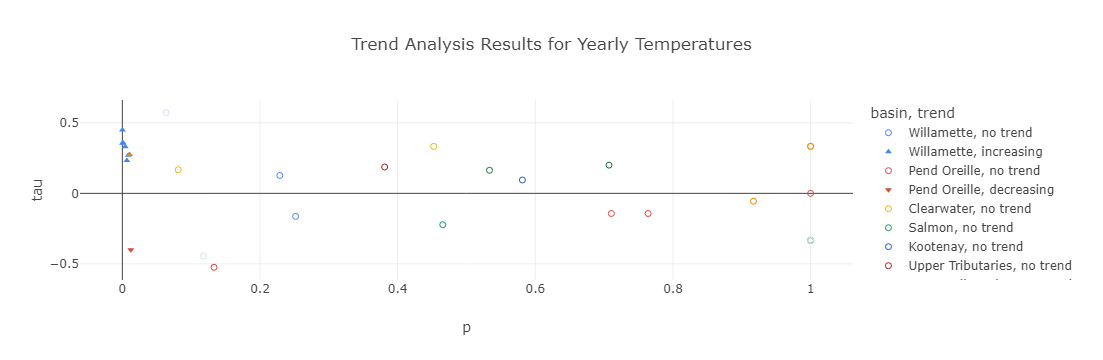

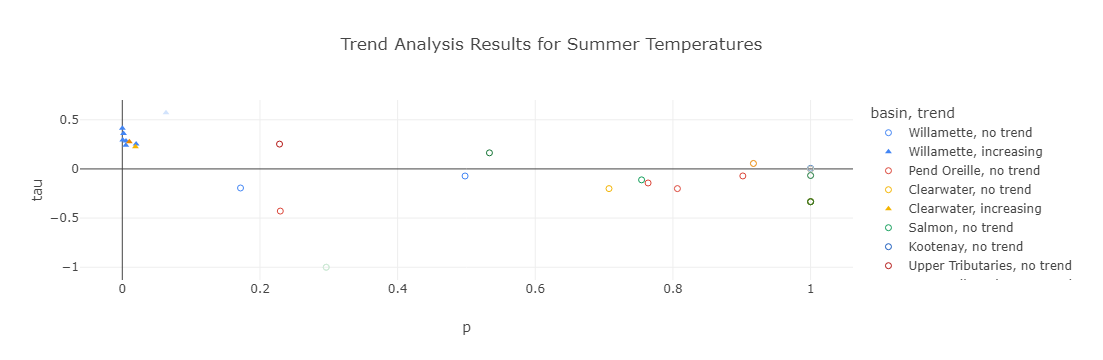

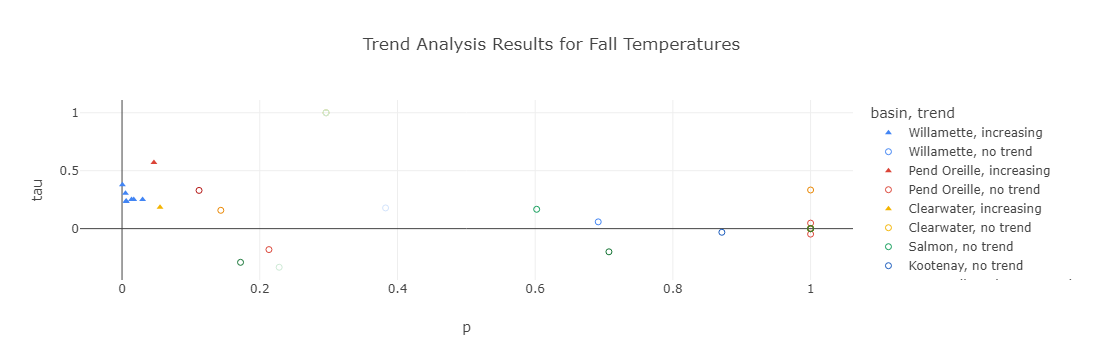

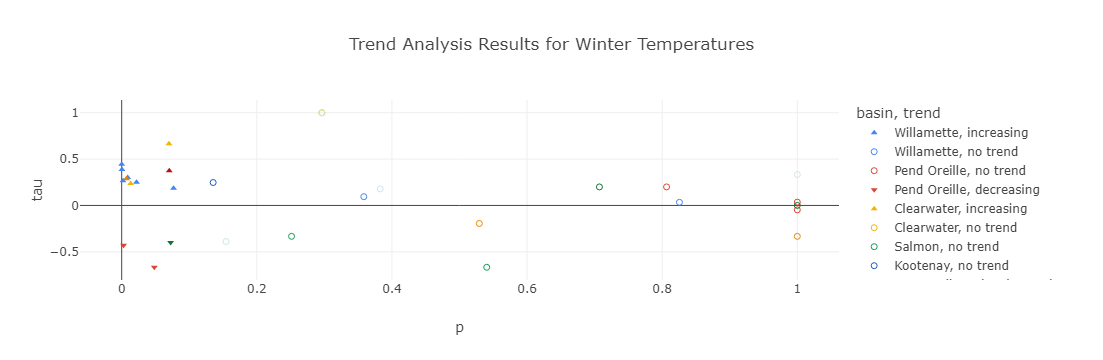

In [70]:
import plotly.express as px
fig = px.scatter(peakT, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Peak Temperature',
                 hover_data={'Basin': peakT['basin'], 'Site': peakT['sites'], 'Trend': peakT['trend'],},
                 symbol = peakT['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))
    
fig = px.scatter(peakTDOY, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Day of Peak Temperature',
                 hover_data={'Basin': peakTDOY['basin'], 'Site': peakTDOY['sites'], 'Trend': peakTDOY['trend'],},
                 symbol = peakTDOY['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(totalT, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Yearly Temperatures',
                 hover_data={'Basin': totalT['basin'], 'Site': totalT['sites'], 'Trend': totalT['trend'],},
                 symbol = totalT['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(summerT, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Summer Temperatures',
                 hover_data={'Basin': summerT['basin'], 'Site': summerT['sites'], 'Trend': summerT['trend'],},
                 symbol = summerT['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(fallT, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Fall Temperatures',
                 hover_data={'Basin': fallT['basin'], 'Site': fallT['sites'], 'Trend': fallT['trend'],},
                 symbol = fallT['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()

with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

# for e in ['decreasing','increasing','no trend']:
    # if e in winterT['trend'].unique():
    #     symbol_sequence= ['circle-open-dot', 'triangle-down', 'triangle-up']
    # else:
    #     symbol_sequence= ['circle-open-dot']

fig = px.scatter(winterT, 'p', 'tau', color='basin',
                 title='Trend Analysis Results for Winter Temperatures',
                 hover_data={'Basin': winterT['basin'], 'Site': winterT['sites'], 'Trend': winterT['trend']},
                 symbol = winterT['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # symbol_sequence=symbol_sequence
                )
                
fig.show()
with open('ModifiedFlowSites_WATERTEMP_MK_Results.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))